In [1]:
# Basic libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Preprocessing 
from sklearn.preprocessing import StandardScaler

# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator

# Model evaluation
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error, explained_variance_score 
from sklearn.model_selection import train_test_split, cross_validate, RepeatedKFold, GridSearchCV

# Algorithms
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor

import joblib

%matplotlib inline

In [ ]:
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid') 

# Checking for all file
os.listdir()

['ml_model.ipynb',
 'train_data.csv',
 'full_tape_manufacturing_process_data.csv',
 'test_data.csv']

In [3]:
 # Set font family for all text in plots
plt.rc('font', family='Times New Roman', weight='bold')

# Set font family for all text in seaborn plots
sns.set_context(rc={"font.size":18, "axes.titlesize":22, "axes.labelsize":25})

In [4]:
# Loading the data
train_data = pd.read_csv('train_data.csv')
test_data = pd.read_csv('test_data.csv')

## Exploratory Data Analysis 

In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tape_id              285 non-null    object 
 1   temperature          285 non-null    float64
 2   doctor_blade         285 non-null    int64  
 3   casting_speed        285 non-null    float64
 4   humidity             285 non-null    int64  
 5   volume_flow_rate     285 non-null    float64
 6   supply_air           285 non-null    int64  
 7   exhaust_air          285 non-null    int64  
 8   green_thickness      285 non-null    int64  
 9   green_density        285 non-null    float64
 10  sintering_thickness  285 non-null    int64  
 11  sintering_density    285 non-null    float64
 12  reducing_thickness   285 non-null    int64  
 13  reducing_density     285 non-null    float64
dtypes: float64(6), int64(7), object(1)
memory usage: 31.3+ KB


In [6]:
train_data.shape, test_data.shape

((285, 14), (72, 14))

In [7]:
# Taking a picture of the data 
train_data.head(10)

,tape_id,temperature,doctor_blade,casting_speed,humidity,volume_flow_rate,supply_air,exhaust_air,green_thickness,green_density,sintering_thickness,sintering_density,reducing_thickness,reducing_density
0,SOC_19,34.8,300,5.0,53,89.57,50,55,96,3.48,90,4.46,86,4.12
1,SOC_25,27.3,300,5.0,35,70.00,40,45,101,3.39,94,4.48,89,4.14
2,SOC_19,33.4,300,5.0,53,90.20,50,55,102,3.42,92,4.74,90,4.25
3,SOC_8,22.4,400,5.0,57,70.91,40,45,149,3.37,134,4.53,129,4.12
4,SOC_17,33.7,300,5.0,50,81.20,45,50,105,3.34,94,4.58,91,4.13
5,SOC_29,39.9,300,5.0,24,87.50,50,55,97,3.47,93,4.51,88,4.15
6,SOC_3,23.6,300,7.5,46,71.56,40,45,96,3.38,87,4.51,84,4.11
7,SOC_7,24.1,200,5.0,52,71.27,40,45,61,3.35,57,4.25,55,3.83
8,SOC_11,26.8,400,5.0,53,69.30,40,45,140,3.46,125,4.74,123,4.24
9,SOC_1,23.1,300,5.0,45,71.48,40,45,94,3.51,91,4.59,88,4.17


In [8]:
train_data.tail(10)

,tape_id,temperature,doctor_blade,casting_speed,humidity,volume_flow_rate,supply_air,exhaust_air,green_thickness,green_density,sintering_thickness,sintering_density,reducing_thickness,reducing_density
275,SOC_15,27.4,200,2.5,54,70.77,40,45,66,3.41,62,4.40,61,3.95
276,SOC_10,27.6,200,5.0,55,69.50,40,45,59,3.47,59,4.33,57,3.87
277,SOC_29,40.1,300,5.0,24,86.30,50,55,92,3.52,90,4.41,85,4.10
278,SOC_4,23.8,300,2.5,45,70.00,40,45,101,3.41,92,4.61,89,4.14
279,SOC_14,27.2,400,2.5,52,70.00,40,45,140,3.47,126,4.75,123,4.26
280,SOC_7,23.5,200,5.0,52,70.63,40,45,64,3.34,61,4.23,59,3.83
281,SOC_9,22.4,500,5.0,59,69.80,40,45,204,3.41,181,4.83,179,4.22
282,SOC_18,23.8,300,5.0,55,91.48,50,55,104,3.40,93,4.70,91,4.21
283,SOC_28,40.6,300,5.0,21,77.70,45,50,90,3.55,89,4.48,84,4.13
284,SOC_9,22.2,500,5.0,59,71.56,40,45,196,3.41,174,4.83,172,4.23


In [9]:
train_data.describe().T.sort_values(by='std', ascending=False)

,count,mean,std,min,25%,50%,75%,max
doctor_blade,285.0,351.578947,90.999719,200.00,300.00,300.00,400.00,500.00
green_thickness,285.0,125.024561,45.062899,58.00,96.00,102.00,162.00,234.00
sintering_thickness,285.0,113.761404,38.568750,57.00,89.00,92.00,144.00,211.00
reducing_thickness,285.0,110.564912,38.555340,55.00,86.00,89.00,142.00,206.00
humidity,285.0,48.112281,10.094694,21.00,45.00,53.00,54.00,59.00
temperature,285.0,29.382456,9.057409,21.70,23.60,26.70,31.00,59.90
volume_flow_rate,285.0,73.090211,6.618527,65.97,69.80,70.58,71.60,91.90
supply_air,285.0,41.596491,3.222170,40.00,40.00,40.00,40.00,50.00
exhaust_air,285.0,46.596491,3.222170,45.00,45.00,45.00,45.00,55.00
casting_speed,285.0,4.438596,1.183328,2.50,5.00,5.00,5.00,7.50


## Analysing numerical variables

In [10]:
warnings.filterwarnings("ignore") # To ignore the warning
# warnings.simplefilter(action='ignore', category=FutureWarning) # To turn off the future warning

# Regarding numerical features
numeric_cols = train_data.select_dtypes(include=['float', 'int']).columns
print("The list of the numerical features: ", numeric_cols)

def _plot_numeric_classes(df, col, bins=10, kde=True):
    sns.histplot(df[col], bins = bins, kde = kde)

def _distribution_numeric(df, numeric_cols, row=3, col=3, figsize=(20, 15), bins=10):
    '''
    numeric_cols..... List of the feature names
    row.............. The number of rows in a single plot
    col.............. The number of columns in a single plot
    figsize.......... A parameter to change the size of a figure 
    bins............. The number of bins in the histogram   
    '''
    print("The number of the numeric field: ", len(numeric_cols))
    assert row*(col-1) < len(numeric_cols)
    plt.figure(figsize = figsize)
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0.5)
    for i in range(1, len(numeric_cols)+1, 1):
        try:
            plt.subplot(row, col, i)
            _plot_numeric_classes(df, numeric_cols[i-1], bins=bins)
            plt.title(numeric_cols[i-1])
        except:
            print("Error {}".format(numeric_cols[i-1]))
            break

The list of the numerical features:  Index(['temperature', 'doctor_blade', 'casting_speed', 'humidity',
       'volume_flow_rate', 'supply_air', 'exhaust_air', 'green_thickness',
       'green_density', 'sintering_thickness', 'sintering_density',
       'reducing_thickness', 'reducing_density'],
      dtype='object')


The number of the numeric field:  13


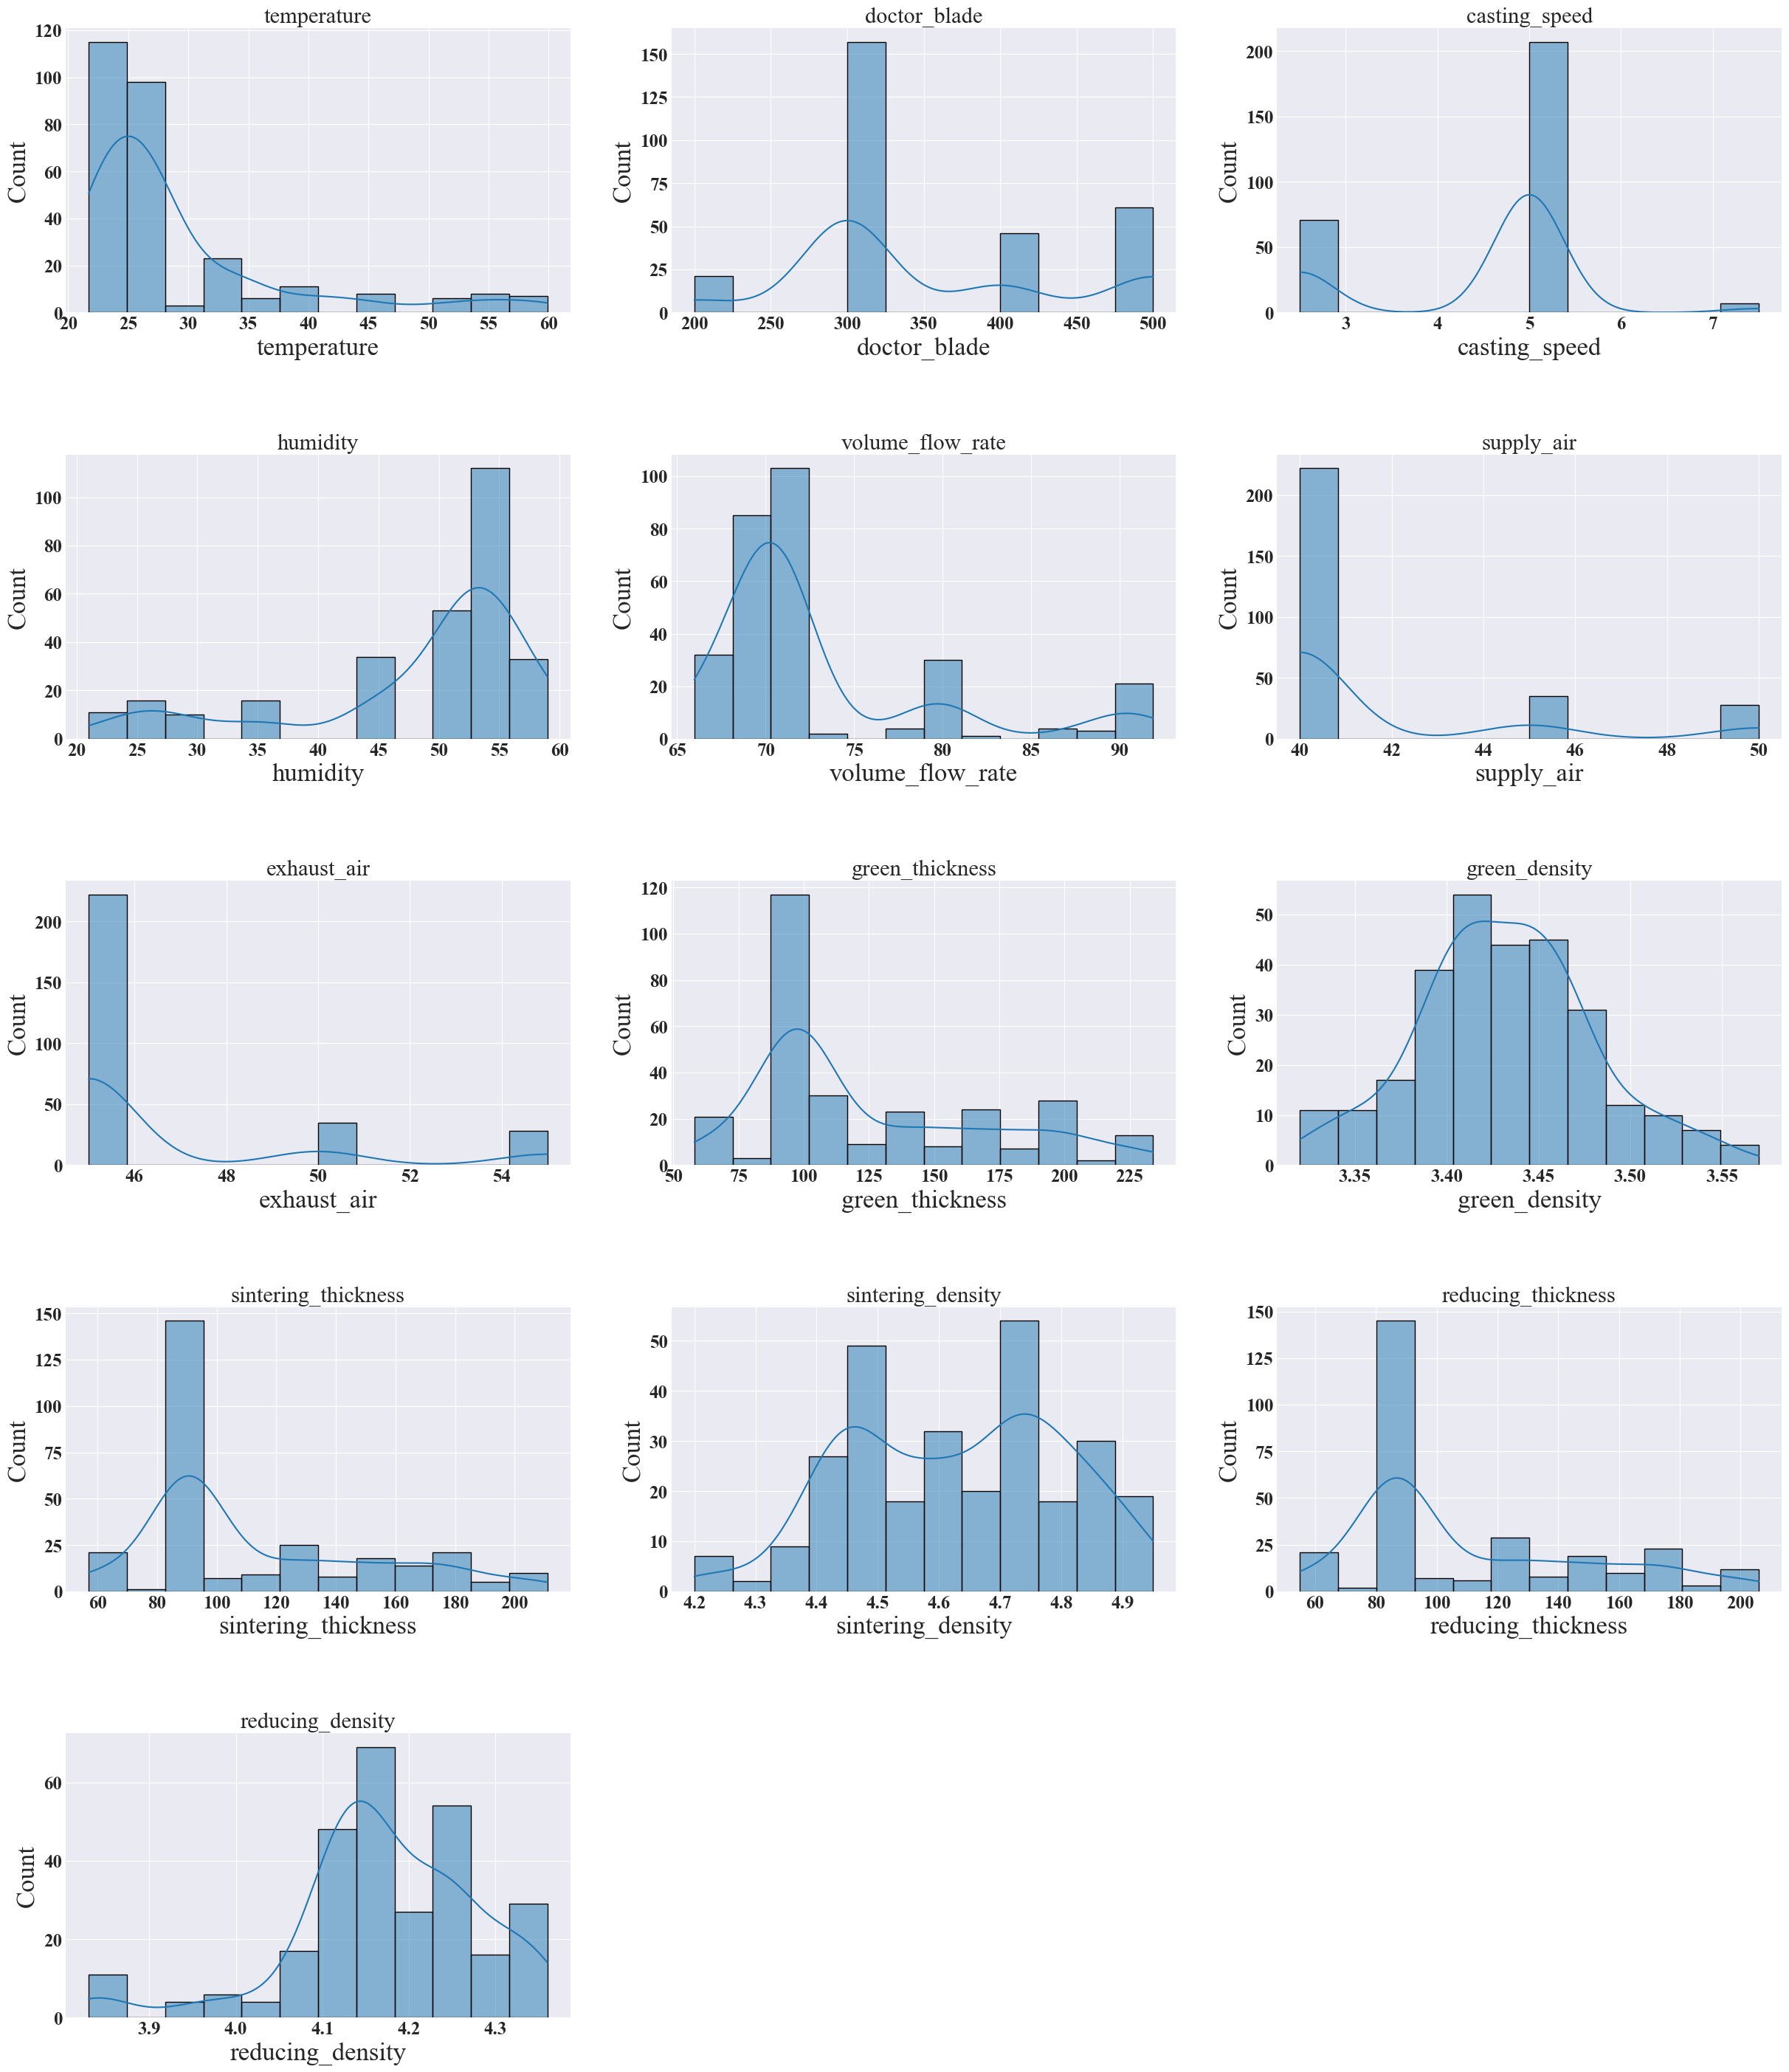

In [11]:
_distribution_numeric(train_data, numeric_cols, 5, 3, (30, 35), 12)

In [12]:
features = numeric_cols.drop(['supply_air', 'exhaust_air', 'sintering_thickness', 'sintering_density', 'reducing_thickness', 'reducing_density'])
features

Index(['temperature', 'doctor_blade', 'casting_speed', 'humidity',
       'volume_flow_rate', 'green_thickness', 'green_density'],
      dtype='object')

## Data Preprocessing

In [16]:
# Split features and target variables for green tape
X_train_green = train_data.drop(['tape_id', 'supply_air', 'exhaust_air', 'green_thickness', 'green_density', 
                           'sintering_thickness', 'sintering_density', 'reducing_thickness', 'reducing_density'], axis=1)
y_green_density_train = train_data['green_density']
y_green_thickness_train = train_data['green_thickness']

In [17]:
X_train_green.shape, y_green_density_train.shape, y_green_thickness_train.shape

((285, 5), (285,), (285,))

In [18]:
# Split features and target variables for sintered tape
X_train_sintering = train_data.drop(['temperature', 'doctor_blade', 'casting_speed', 'humidity', 'volume_flow_rate', 'supply_air', 'exhaust_air',  
                                     'sintering_thickness', 'sintering_density', 'reducing_thickness', 'reducing_density'], axis=1)
y_sintered_density_train = train_data['sintering_density']
y_sintered_thickness_train = train_data['sintering_thickness']

In [19]:
X_train_sintering.shape, y_sintered_density_train.shape, y_sintered_thickness_train.shape

((285, 3), (285,), (285,))

In [20]:
# Split features and target variables for reduced tape
X_train_reducing = train_data.drop(['temperature', 'doctor_blade', 'casting_speed', 'humidity', 'volume_flow_rate', 'supply_air', 'exhaust_air',  
                                     'green_thickness', 'green_density', 'reducing_thickness', 'reducing_density'], axis=1)
y_reduced_density_train = train_data['reducing_density']
y_reduced_thickness_train = train_data['reducing_thickness']

In [21]:
X_train_reducing.shape, y_reduced_density_train.shape, y_reduced_thickness_train.shape

((285, 3), (285,), (285,))

## Multiple-models Fine-tuning

In [22]:
# RepeatedKFold
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=42)

In [23]:
class RegressorSwitcher(BaseEstimator):
    def __init__(
            self,
            estimator=LinearRegression()
    ):
        """
         A custom BaseEstimator that can switch between regressors.
         :param estimator: sklearn object - The regressor
        """
        self.estimator = estimator
    
    def fit(self, X, y=None, **kwargs):
        self.estimator.fit(X, y)
        return self
    
    def predict(self, X, y=None):
        return self.estimator.predict(X)
    

    def score(self, X, y):
        return self.estimator.score(X, y)

### GridSearch for green density model

In [24]:
pipeline = Pipeline([('scaler', StandardScaler()),
                     ('rg', RegressorSwitcher())])
                    
parameters = [
    {
        'rg__estimator': [LinearRegression()]
    },
    {
        'rg__estimator': [Ridge()],
        'rg__estimator__alpha': [0.001, 0.01, 0.1, 1, 5, 10, 20, 100]
    },
    {
        'rg__estimator': [SVR()],
        'rg__estimator__kernel': ('rbf', 'sigmoid', 'poly', 'linear'),
        'rg__estimator__C': np.arange(3.0, 6.1, 0.1)
    },
    {
        'rg__estimator': [KNeighborsRegressor()],
        'rg__estimator__weights': ['uniform', 'distance'],
        'rg__estimator__n_neighbors': list(range(1, 20))
    },
    {
        'rg__estimator':[DecisionTreeRegressor(random_state=42)],
        'rg__estimator__splitter': ('best', 'random'),
        'rg__estimator__max_depth': [3, 4, 5, None],
        'rg__estimator__min_samples_split': [2, 3, 5, 10],
        'rg__estimator__min_samples_leaf': [1, 2, 3, 4, 5],        
    },
    {
        'rg__estimator': [RandomForestRegressor(random_state=42)],
        'rg__estimator__n_estimators': [100, 300, 500],
        'rg__estimator__max_features': ['log2', 'sqrt', None],
        'rg__estimator__max_depth': [3, 4, 5, None],
        'rg__estimator__min_samples_split': [2, 3, 5, 10],
        'rg__estimator__min_samples_leaf': [1, 2, 3, 4, 5],
        'rg__estimator__bootstrap': [True, False]
    },
    {
        'rg__estimator': [GradientBoostingRegressor(random_state=42)],
        'rg__estimator__learning_rate': [0.01, 0.1],
        'rg__estimator__n_estimators': [100, 300, 500],
        'rg__estimator__max_depth': [3, 4, 5, None],
        'rg__estimator__min_samples_split': [2, 3, 5, 10],
        'rg__estimator__min_samples_leaf': [1, 2, 3, 4, 5]
    },
    {
        'rg__estimator': [ExtraTreesRegressor(random_state=42)],
        'rg__estimator__n_estimators': [100, 300, 500],
        'rg__estimator__max_features': ['log2', 'sqrt', None, 0.9, 0.95, 0.85],
        'rg__estimator__max_depth': [3, 4, 5, None],
        'rg__estimator__min_samples_split': [2, 3, 5, 10],
        'rg__estimator__min_samples_leaf': [1, 2, 3, 4, 5],
        'rg__estimator__bootstrap': [True, False]
    }
]

green_density_gscv = GridSearchCV(pipeline, parameters, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)

In [25]:
# Checkinig the execution steps
print('Step: ', pipeline.steps[0])
print('Step: ', pipeline.steps[1])

Step:  ('scaler', StandardScaler())
Step:  ('rg', RegressorSwitcher())


In [26]:
green_density_gscv.fit(X_train_green, y_green_density_train)

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=42),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('rg', RegressorSwitcher())]),
             n_jobs=-1,
             param_grid=[{'rg__estimator': [LinearRegression()]},
                         {'rg__estimator': [Ridge()],
                          'rg__estimator__alpha': [0.001, 0.01, 0.1, 1, 5, 10,
                                                   20, 100]},
                         {'rg__estimator': [SVR()],
                          'rg__estimator__C': array([3....
                         {'rg__estimator': [ExtraTreesRegressor(random_state=42)],
                          'rg__estimator__bootstrap': [True, False],
                          'rg__estimator__max_depth': [3, 4, 5, None],
                          'rg__estimator__max_features': ['log2', 'sqrt', None,
                                                          0.9, 0.95, 0.85],
                          'rg__estimator__min_samples_leaf': [1, 2, 3, 4, 5],
                          'rg__estimator__min_samples_split': [2, 3, 5, 10],
                          'rg__estimator__n_estimators': [100, 300, 500]}],
             scoring='neg_mean_squared_error')

In [27]:
print("Best MSE score of the green density model:", -green_density_gscv.best_score_)
print('The best estimator of the green density model is ', green_density_gscv.best_estimator_) # The best model corresponding to MSE score
print("Best parameters of the green density model:", green_density_gscv.best_params_)

Best MSE score of the green density model: 0.00038494361773628894
The best estimator of the green density model is  Pipeline(steps=[('scaler', StandardScaler()),
                ('rg',
                 RegressorSwitcher(estimator=ExtraTreesRegressor(max_features=None,
                                                                 min_samples_split=3,
                                                                 random_state=42)))])
Best parameters of the green density model: {'rg__estimator': ExtraTreesRegressor(random_state=42), 'rg__estimator__bootstrap': False, 'rg__estimator__max_depth': None, 'rg__estimator__max_features': None, 'rg__estimator__min_samples_leaf': 1, 'rg__estimator__min_samples_split': 3, 'rg__estimator__n_estimators': 100}


In [28]:
# Get the cv_results_
green_density_gscv.cv_results_

{'mean_fit_time': array([0.00562785, 0.00623132, 0.00586564, ..., 0.08674894, 0.25879976,
        0.38469162]),
 'std_fit_time': array([0.00078827, 0.00260894, 0.00127403, ..., 0.00556955, 0.05133026,
        0.08513977]),
 'mean_score_time': array([0.00225227, 0.00243434, 0.00258585, ..., 0.0069093 , 0.01596122,
        0.02118466]),
 'std_score_time': array([0.00021455, 0.00071454, 0.00086662, ..., 0.00105078, 0.00360511,
        0.01004805]),
 'param_rg__estimator': masked_array(data=[LinearRegression(), Ridge(), Ridge(), ...,
                    ExtraTreesRegressor(random_state=42),
                    ExtraTreesRegressor(random_state=42),
                    ExtraTreesRegressor(random_state=42)],
              mask=[False, False, False, ..., False, False, False],
        fill_value='?',
             dtype=object),
 'param_rg__estimator__alpha': masked_array(data=[--, 0.001, 0.01, ..., --, --, --],
              mask=[ True, False, False, ...,  True,  True,  True],
        fill_val

In [29]:
green_density_result_df = pd.DataFrame(green_density_gscv.cv_results_)
green_density_model = green_density_result_df[['mean_test_score', 'std_test_score', 'rank_test_score', 'params']].copy()
green_density_model['model_name'] = green_density_gscv.cv_results_['param_rg__estimator']
green_density_model = green_density_model[['model_name', 'mean_test_score', 'std_test_score', 'rank_test_score', 'params']]
green_density_model = green_density_model.sort_values(by='mean_test_score', ascending=False)

In [30]:
# Export the green_density_model.csv
green_density_model.to_csv('green_density_model.csv', index=False)

### GridSearch for green thickness model

In [31]:
green_thickness_gscv = GridSearchCV(pipeline, parameters, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)

In [32]:
green_thickness_gscv.fit(X_train_green, y_green_thickness_train)

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=42),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('rg', RegressorSwitcher())]),
             n_jobs=-1,
             param_grid=[{'rg__estimator': [LinearRegression()]},
                         {'rg__estimator': [Ridge()],
                          'rg__estimator__alpha': [0.001, 0.01, 0.1, 1, 5, 10,
                                                   20, 100]},
                         {'rg__estimator': [SVR()],
                          'rg__estimator__C': array([3....
                         {'rg__estimator': [ExtraTreesRegressor(random_state=42)],
                          'rg__estimator__bootstrap': [True, False],
                          'rg__estimator__max_depth': [3, 4, 5, None],
                          'rg__estimator__max_features': ['log2', 'sqrt', None,
                                                          0.9, 0.95, 0.85],
                          'rg__estimator__min_samples_leaf': [1, 2, 3, 4, 5],
                          'rg__estimator__min_samples_split': [2, 3, 5, 10],
                          'rg__estimator__n_estimators': [100, 300, 500]}],
             scoring='neg_mean_squared_error')

In [33]:
print("Best MSE score of the green thickness model:", -green_thickness_gscv.best_score_)
print('The best estimator of the green thickness model is ', green_thickness_gscv.best_estimator_) # The best model corresponding to MSE score
print("Best parameters of the green thickness model:", green_thickness_gscv.best_params_)

Best MSE score of the green thickness model: 18.478020641071744
The best estimator of the green thickness model is  Pipeline(steps=[('scaler', StandardScaler()),
                ('rg',
                 RegressorSwitcher(estimator=ExtraTreesRegressor(max_features=0.9,
                                                                 n_estimators=300,
                                                                 random_state=42)))])
Best parameters of the green thickness model: {'rg__estimator': ExtraTreesRegressor(random_state=42), 'rg__estimator__bootstrap': False, 'rg__estimator__max_depth': None, 'rg__estimator__max_features': 0.9, 'rg__estimator__min_samples_leaf': 1, 'rg__estimator__min_samples_split': 2, 'rg__estimator__n_estimators': 300}


In [34]:
# Get the cv_results_
green_thickness_gscv.cv_results_

{'mean_fit_time': array([0.00453777, 0.00606691, 0.00382884, ..., 0.08827302, 0.25062242,
        0.3798651 ]),
 'std_fit_time': array([0.00144741, 0.00146609, 0.00175323, ..., 0.00680151, 0.0190105 ,
        0.08257484]),
 'mean_score_time': array([0.00189397, 0.0025908 , 0.00143075, ..., 0.00724853, 0.01617769,
        0.02009339]),
 'std_score_time': array([0.00065062, 0.00065059, 0.00065251, ..., 0.00118714, 0.00282332,
        0.01063143]),
 'param_rg__estimator': masked_array(data=[LinearRegression(), Ridge(), Ridge(), ...,
                    ExtraTreesRegressor(random_state=42),
                    ExtraTreesRegressor(random_state=42),
                    ExtraTreesRegressor(random_state=42)],
              mask=[False, False, False, ..., False, False, False],
        fill_value='?',
             dtype=object),
 'param_rg__estimator__alpha': masked_array(data=[--, 0.001, 0.01, ..., --, --, --],
              mask=[ True, False, False, ...,  True,  True,  True],
        fill_val

In [35]:
green_thickness_result_df = pd.DataFrame(green_thickness_gscv.cv_results_)
green_thickness_model = green_thickness_result_df[['mean_test_score', 'std_test_score', 'rank_test_score', 'params']].copy()
green_thickness_model['model_name'] = green_thickness_gscv.cv_results_['param_rg__estimator']
green_thickness_model = green_thickness_model[['model_name', 'mean_test_score', 'std_test_score', 'rank_test_score', 'params']]
green_thickness_model = green_thickness_model.sort_values(by='mean_test_score', ascending=False)

In [36]:
# Export the green_thickness_model.csv
green_thickness_model.to_csv('green_thickness_model.csv', index=False)

### GridSearch for sintered density model

In [37]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(drop='first', sparse_output=False), ['tape_id']),
        ('scaler', StandardScaler(), ['green_thickness', 'green_density'])
    ]
)

pipeline_1 = Pipeline([('preprocessor', preprocessor),
                     ('rg', RegressorSwitcher())])

In [38]:
sintered_density_gscv = GridSearchCV(pipeline_1, parameters, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)
sintered_density_gscv.fit(X_train_sintering, y_sintered_density_train)

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=42),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('one_hot',
                                                                         OneHotEncoder(drop='first',
                                                                                       sparse_output=False),
                                                                         ['tape_id']),
                                                                        ('scaler',
                                                                         StandardScaler(),
                                                                         ['green_thickness',
                                                                          'green_density'])])),
                                       ('rg', RegressorSwitcher())]),
             n_jobs=-1,
             param_grid=[{'rg__estimator...
                         {'rg__estimator': [ExtraTreesRegressor(random_state=42)],
                          'rg__estimator__bootstrap': [True, False],
                          'rg__estimator__max_depth': [3, 4, 5, None],
                          'rg__estimator__max_features': ['log2', 'sqrt', None,
                                                          0.9, 0.95, 0.85],
                          'rg__estimator__min_samples_leaf': [1, 2, 3, 4, 5],
                          'rg__estimator__min_samples_split': [2, 3, 5, 10],
                          'rg__estimator__n_estimators': [100, 300, 500]}],
             scoring='neg_mean_squared_error')

In [39]:
print("Best MSE score of the green thickness model:", -sintered_density_gscv.best_score_)
print('The best estimator of the green thickness model is ', sintered_density_gscv.best_estimator_) # The best model corresponding to MSE score
print("Best parameters of the green thickness model:", sintered_density_gscv.best_params_)

Best MSE score of the green thickness model: 0.0008708054317475069
The best estimator of the green thickness model is  Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('one_hot',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['tape_id']),
                                                 ('scaler', StandardScaler(),
                                                  ['green_thickness',
                                                   'green_density'])])),
                ('rg',
                 RegressorSwitcher(estimator=ExtraTreesRegressor(max_features='sqrt',
                                                                 random_state=42)))])
Best parameters of the green thickness model: {'rg__estimator': ExtraTreesRegressor(random_state=42), 'rg__estimator__bootstrap': False, 'rg__e

In [40]:
# Get the cv_results_
sintered_density_gscv.cv_results_

{'mean_fit_time': array([0.0084055 , 0.0080168 , 0.0070046 , ..., 0.11295474, 0.29639217,
        0.45053707]),
 'std_fit_time': array([0.00244902, 0.00196148, 0.00205728, ..., 0.03754094, 0.03345625,
        0.07545126]),
 'mean_score_time': array([0.00438268, 0.00391581, 0.00337791, ..., 0.01038794, 0.01830122,
        0.02148105]),
 'std_score_time': array([0.00143524, 0.00088122, 0.00097562, ..., 0.00478032, 0.00358809,
        0.00932279]),
 'param_rg__estimator': masked_array(data=[LinearRegression(), Ridge(), Ridge(), ...,
                    ExtraTreesRegressor(random_state=42),
                    ExtraTreesRegressor(random_state=42),
                    ExtraTreesRegressor(random_state=42)],
              mask=[False, False, False, ..., False, False, False],
        fill_value='?',
             dtype=object),
 'param_rg__estimator__alpha': masked_array(data=[--, 0.001, 0.01, ..., --, --, --],
              mask=[ True, False, False, ...,  True,  True,  True],
        fill_val

In [41]:
sintered_density_result_df = pd.DataFrame(sintered_density_gscv.cv_results_)
sintered_density_model = sintered_density_result_df[['mean_test_score', 'std_test_score', 'rank_test_score', 'params']].copy()
sintered_density_model['model_name'] = sintered_density_gscv.cv_results_['param_rg__estimator']
sintered_density_model = sintered_density_model[['model_name', 'mean_test_score', 'std_test_score', 'rank_test_score', 'params']]
sintered_density_model = sintered_density_model.sort_values(by='mean_test_score', ascending=False)
# Export the sintered_density_model.csv
sintered_density_model.to_csv('sintered_density_model.csv', index=False)

### GridSearch for sintered thickness model

In [42]:
sintered_thickness_gscv = GridSearchCV(pipeline_1, parameters, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)
sintered_thickness_gscv.fit(X_train_sintering, y_sintered_thickness_train)

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=42),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('one_hot',
                                                                         OneHotEncoder(drop='first',
                                                                                       sparse_output=False),
                                                                         ['tape_id']),
                                                                        ('scaler',
                                                                         StandardScaler(),
                                                                         ['green_thickness',
                                                                          'green_density'])])),
                                       ('rg', RegressorSwitcher())]),
             n_jobs=-1,
             param_grid=[{'rg__estimator...
                         {'rg__estimator': [ExtraTreesRegressor(random_state=42)],
                          'rg__estimator__bootstrap': [True, False],
                          'rg__estimator__max_depth': [3, 4, 5, None],
                          'rg__estimator__max_features': ['log2', 'sqrt', None,
                                                          0.9, 0.95, 0.85],
                          'rg__estimator__min_samples_leaf': [1, 2, 3, 4, 5],
                          'rg__estimator__min_samples_split': [2, 3, 5, 10],
                          'rg__estimator__n_estimators': [100, 300, 500]}],
             scoring='neg_mean_squared_error')

In [43]:
print("Best MSE score of the green thickness model:", -sintered_thickness_gscv.best_score_)
print('The best estimator of the green thickness model is ', sintered_thickness_gscv.best_estimator_) # The best model corresponding to MSE score
print("Best parameters of the green thickness model:", sintered_thickness_gscv.best_params_)

Best MSE score of the green thickness model: 0.622298608830505
The best estimator of the green thickness model is  Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('one_hot',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['tape_id']),
                                                 ('scaler', StandardScaler(),
                                                  ['green_thickness',
                                                   'green_density'])])),
                ('rg',
                 RegressorSwitcher(estimator=ExtraTreesRegressor(max_features=None,
                                                                 n_estimators=300,
                                                                 random_state=42)))])
Best parameters of the green thickness model: {'rg__estimator': Ex

In [44]:
# Get the cv_results_
sintered_thickness_gscv.cv_results_

{'mean_fit_time': array([0.00706514, 0.00751592, 0.00632029, ..., 0.10843054, 0.31919649,
        0.4586518 ]),
 'std_fit_time': array([0.00216156, 0.00164561, 0.00161115, ..., 0.01399159, 0.06227542,
        0.08625476]),
 'mean_score_time': array([0.00378534, 0.00380023, 0.00316129, ..., 0.01009533, 0.01830118,
        0.02143154]),
 'std_score_time': array([0.00109657, 0.00079122, 0.00071755, ..., 0.00431528, 0.00356762,
        0.00838997]),
 'param_rg__estimator': masked_array(data=[LinearRegression(), Ridge(), Ridge(), ...,
                    ExtraTreesRegressor(random_state=42),
                    ExtraTreesRegressor(random_state=42),
                    ExtraTreesRegressor(random_state=42)],
              mask=[False, False, False, ..., False, False, False],
        fill_value='?',
             dtype=object),
 'param_rg__estimator__alpha': masked_array(data=[--, 0.001, 0.01, ..., --, --, --],
              mask=[ True, False, False, ...,  True,  True,  True],
        fill_val

In [45]:
sintered_thickness_result_df = pd.DataFrame(sintered_thickness_gscv.cv_results_)
sintered_thickness_model = sintered_thickness_result_df[['mean_test_score', 'std_test_score', 'rank_test_score', 'params']].copy()
sintered_thickness_model['model_name'] = sintered_thickness_gscv.cv_results_['param_rg__estimator']
sintered_thickness_model = sintered_thickness_model[['model_name', 'mean_test_score', 'std_test_score', 'rank_test_score', 'params']]
sintered_thickness_model = sintered_thickness_model.sort_values(by='mean_test_score', ascending=False)
# Export the sintered_thickness_model.csv
sintered_thickness_model.to_csv('sintered_thickness_model.csv', index=False)

### GridSearch for reduced density model

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(drop='first', sparse_output=False), ['tape_id']),
        ('scaler', StandardScaler(), ['sintering_thickness', 'sintering_density'])
    ]
)

pipeline_2 = Pipeline([('preprocessor', preprocessor),
                     ('rg', RegressorSwitcher())])

In [47]:
reduced_density_gscv = GridSearchCV(pipeline_2, parameters, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)
reduced_density_gscv.fit(X_train_reducing, y_reduced_density_train)

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=42),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('one_hot',
                                                                         OneHotEncoder(drop='first',
                                                                                       sparse_output=False),
                                                                         ['tape_id']),
                                                                        ('scaler',
                                                                         StandardScaler(),
                                                                         ['sintering_thickness',
                                                                          'sintering_density'])])),
                                       ('rg', RegressorSwitcher())]),
             n_jobs=-1,
             param_grid=[{'rg__e...
                         {'rg__estimator': [ExtraTreesRegressor(random_state=42)],
                          'rg__estimator__bootstrap': [True, False],
                          'rg__estimator__max_depth': [3, 4, 5, None],
                          'rg__estimator__max_features': ['log2', 'sqrt', None,
                                                          0.9, 0.95, 0.85],
                          'rg__estimator__min_samples_leaf': [1, 2, 3, 4, 5],
                          'rg__estimator__min_samples_split': [2, 3, 5, 10],
                          'rg__estimator__n_estimators': [100, 300, 500]}],
             scoring='neg_mean_squared_error')

In [48]:
print("Best MSE score of the green thickness model:", -reduced_density_gscv.best_score_)
print('The best estimator of the green thickness model is ', reduced_density_gscv.best_estimator_) # The best model corresponding to MSE score
print("Best parameters of the green thickness model:", reduced_density_gscv.best_params_)

Best MSE score of the green thickness model: 6.137007665649948e-05
The best estimator of the green thickness model is  Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('one_hot',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['tape_id']),
                                                 ('scaler', StandardScaler(),
                                                  ['sintering_thickness',
                                                   'sintering_density'])])),
                ('rg', RegressorSwitcher(estimator=Ridge(alpha=0.01)))])
Best parameters of the green thickness model: {'rg__estimator': Ridge(), 'rg__estimator__alpha': 0.01}


In [49]:
# Get the cv_results_
reduced_density_gscv.cv_results_

{'mean_fit_time': array([0.0063049 , 0.00825264, 0.00582378, ..., 0.10684016, 0.29541408,
        0.44206407]),
 'std_fit_time': array([0.00176094, 0.00238522, 0.00162292, ..., 0.03556625, 0.05154807,
        0.09073427]),
 'mean_score_time': array([0.00315706, 0.00413227, 0.00328612, ..., 0.00920626, 0.01953354,
        0.02154739]),
 'std_score_time': array([0.00091893, 0.00145825, 0.00080981, ..., 0.00211086, 0.00719117,
        0.00873525]),
 'param_rg__estimator': masked_array(data=[LinearRegression(), Ridge(), Ridge(), ...,
                    ExtraTreesRegressor(random_state=42),
                    ExtraTreesRegressor(random_state=42),
                    ExtraTreesRegressor(random_state=42)],
              mask=[False, False, False, ..., False, False, False],
        fill_value='?',
             dtype=object),
 'param_rg__estimator__alpha': masked_array(data=[--, 0.001, 0.01, ..., --, --, --],
              mask=[ True, False, False, ...,  True,  True,  True],
        fill_val

In [50]:
reduced_density_result_df = pd.DataFrame(reduced_density_gscv.cv_results_)
reduced_density_model = reduced_density_result_df[['mean_test_score', 'std_test_score', 'rank_test_score', 'params']].copy()
reduced_density_model['model_name'] = reduced_density_gscv.cv_results_['param_rg__estimator']
reduced_density_model = reduced_density_model[['model_name', 'mean_test_score', 'std_test_score', 'rank_test_score', 'params']]
reduced_density_model = reduced_density_model.sort_values(by='mean_test_score', ascending=False)
# Export the reduced_density_model.csv
reduced_density_model.to_csv('reduced_density_model.csv', index=False)

### GridSearch for reduced thickness model

In [51]:
reduced_thickness_gscv = GridSearchCV(pipeline_2, parameters, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)
reduced_thickness_gscv.fit(X_train_reducing, y_reduced_thickness_train)

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=42),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('one_hot',
                                                                         OneHotEncoder(drop='first',
                                                                                       sparse_output=False),
                                                                         ['tape_id']),
                                                                        ('scaler',
                                                                         StandardScaler(),
                                                                         ['sintering_thickness',
                                                                          'sintering_density'])])),
                                       ('rg', RegressorSwitcher())]),
             n_jobs=-1,
             param_grid=[{'rg__e...
                         {'rg__estimator': [ExtraTreesRegressor(random_state=42)],
                          'rg__estimator__bootstrap': [True, False],
                          'rg__estimator__max_depth': [3, 4, 5, None],
                          'rg__estimator__max_features': ['log2', 'sqrt', None,
                                                          0.9, 0.95, 0.85],
                          'rg__estimator__min_samples_leaf': [1, 2, 3, 4, 5],
                          'rg__estimator__min_samples_split': [2, 3, 5, 10],
                          'rg__estimator__n_estimators': [100, 300, 500]}],
             scoring='neg_mean_squared_error')

In [52]:
print("Best MSE score of the green thickness model:", -reduced_thickness_gscv.best_score_)
print('The best estimator of the green thickness model is ', reduced_thickness_gscv.best_estimator_) # The best model corresponding to MSE score
print("Best parameters of the green thickness model:", reduced_thickness_gscv.best_params_)

Best MSE score of the green thickness model: 0.09341220942338292
The best estimator of the green thickness model is  Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('one_hot',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['tape_id']),
                                                 ('scaler', StandardScaler(),
                                                  ['sintering_thickness',
                                                   'sintering_density'])])),
                ('rg', RegressorSwitcher())])
Best parameters of the green thickness model: {'rg__estimator': LinearRegression()}


In [53]:
# Get the cv_results_
reduced_thickness_gscv.cv_results_

{'mean_fit_time': array([0.00584408, 0.00594148, 0.00780694, ..., 0.10884638, 0.31732363,
        0.49744459]),
 'std_fit_time': array([0.0016248 , 0.0012979 , 0.00408134, ..., 0.00618009, 0.02279064,
        0.06124524]),
 'mean_score_time': array([0.00326107, 0.00318892, 0.00393114, ..., 0.00977033, 0.01970132,
        0.02431572]),
 'std_score_time': array([0.00075319, 0.00080237, 0.00061604, ..., 0.00127757, 0.00350392,
        0.00762735]),
 'param_rg__estimator': masked_array(data=[LinearRegression(), Ridge(), Ridge(), ...,
                    ExtraTreesRegressor(random_state=42),
                    ExtraTreesRegressor(random_state=42),
                    ExtraTreesRegressor(random_state=42)],
              mask=[False, False, False, ..., False, False, False],
        fill_value='?',
             dtype=object),
 'param_rg__estimator__alpha': masked_array(data=[--, 0.001, 0.01, ..., --, --, --],
              mask=[ True, False, False, ...,  True,  True,  True],
        fill_val

In [54]:
reduced_thickness_result_df = pd.DataFrame(reduced_thickness_gscv.cv_results_)
reduced_thickness_model = reduced_thickness_result_df[['mean_test_score', 'std_test_score', 'rank_test_score', 'params']].copy()
reduced_thickness_model['model_name'] = reduced_thickness_gscv.cv_results_['param_rg__estimator']
reduced_thickness_model = reduced_thickness_model[['model_name', 'mean_test_score', 'std_test_score', 'rank_test_score', 'params']]
reduced_thickness_model = reduced_thickness_model.sort_values(by='mean_test_score', ascending=False)
# Export the reduced_thickness_model.csv
reduced_thickness_model.to_csv('reduced_thickness_model.csv', index=False)